In [1]:
 import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('drive/MyDrive/Datasets/demand_forecasting.csv')

In [3]:
df.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69


In [4]:
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84
75999,2024-01-30,S005,P0020,Toys,North,126,63,59,25.78,10,Snowy,0,29.32,Winter,0,73


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [6]:
# Converting the date column to datetime like value
df['Date'] = pd.to_datetime(df['Date'])

# Extracting month and day from date
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [7]:
# Creating a cyclical feature for month
df['Month_Sin'] = np.sin(2*np.pi*df['Month']/12)
df['Month_Cos'] = np.cos(2*np.pi*df['Month']/12)

In [8]:
# Creating a cyclical feature for day of week
df['DayOfWeek_Sin'] = np.sin(2*np.pi*df['DayOfWeek']/7)
df['DayOfWeek_Cos'] = np.cos(2*np.pi*df['DayOfWeek']/7)

In [9]:
# Creating a time step
start_date = df['Date'].min()
df['Time_Step'] = (df['Date']-start_date).dt.days

In [10]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Seasonality,Epidemic,Demand,Month,DayOfWeek,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos,Time_Step
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,Winter,0,115,1,5,0.5,0.866025,-0.974928,-0.222521,0
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,Winter,0,229,1,5,0.5,0.866025,-0.974928,-0.222521,0
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,Winter,0,157,1,5,0.5,0.866025,-0.974928,-0.222521,0
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,Winter,0,52,1,5,0.5,0.866025,-0.974928,-0.222521,0
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,Winter,0,59,1,5,0.5,0.866025,-0.974928,-0.222521,0


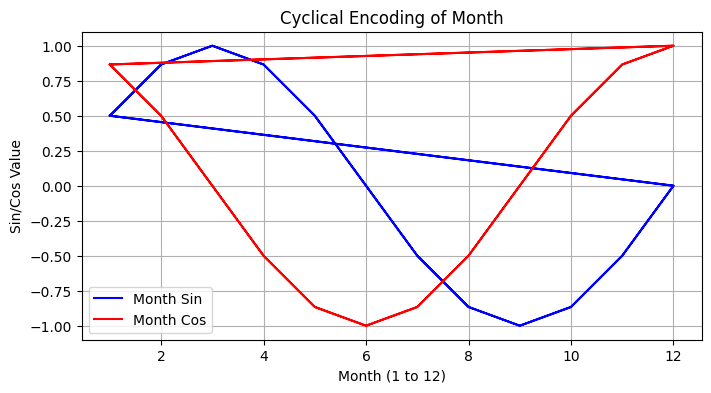

In [11]:
# Plotting

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(df['Month'], df['Month_Sin'], label='Month Sin', color='blue')
plt.plot(df['Month'], df['Month_Cos'], label='Month Cos', color='red')
plt.xlabel('Month (1 to 12)')
plt.ylabel('Sin/Cos Value')
plt.title('Cyclical Encoding of Month')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Removing the columns we don't need

df = df.drop(['Inventory Level', 'Product ID', 'Units Sold', 'Units Ordered', 'Seasonality', 'Month', 'DayOfWeek', 'Date', 'Store ID'], axis = 1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Category            76000 non-null  object 
 1   Region              76000 non-null  object 
 2   Price               76000 non-null  float64
 3   Discount            76000 non-null  int64  
 4   Weather Condition   76000 non-null  object 
 5   Promotion           76000 non-null  int64  
 6   Competitor Pricing  76000 non-null  float64
 7   Epidemic            76000 non-null  int64  
 8   Demand              76000 non-null  int64  
 9   Month_Sin           76000 non-null  float64
 10  Month_Cos           76000 non-null  float64
 11  DayOfWeek_Sin       76000 non-null  float64
 12  DayOfWeek_Cos       76000 non-null  float64
 13  Time_Step           76000 non-null  int64  
dtypes: float64(6), int64(5), object(3)
memory usage: 8.1+ MB


In [13]:
# calculate price gap as a percentage difference relative to the competitor

df['Price_Gap'] = ((df['Price'] - df['Competitor Pricing']) / df['Competitor Pricing']) * 100

In [14]:
df.head()

,Category,Region,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Epidemic,Demand,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos,Time_Step,Price_Gap
0,Electronics,North,72.72,5,Snowy,0,85.73,0,115,0.5,0.866025,-0.974928,-0.222521,0,-15.175551
1,Clothing,North,80.16,15,Snowy,1,92.02,0,229,0.5,0.866025,-0.974928,-0.222521,0,-12.888502
2,Clothing,North,62.94,10,Snowy,1,60.08,0,157,0.5,0.866025,-0.974928,-0.222521,0,4.760320
3,Electronics,North,87.63,10,Snowy,0,85.19,0,52,0.5,0.866025,-0.974928,-0.222521,0,2.864186
4,Groceries,North,54.41,0,Snowy,0,51.63,0,59,0.5,0.866025,-0.974928,-0.222521,0,5.384466


In [15]:
df['Weather Condition'].unique()

array(['Snowy', 'Cloudy', 'Sunny', 'Rainy'], dtype=object)

In [16]:
promotion_effect = df.groupby('Promotion')['Demand'].mean()
print(promotion_effect)

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64


In [17]:
df.head()

,Category,Region,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Epidemic,Demand,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos,Time_Step,Price_Gap
0,Electronics,North,72.72,5,Snowy,0,85.73,0,115,0.5,0.866025,-0.974928,-0.222521,0,-15.175551
1,Clothing,North,80.16,15,Snowy,1,92.02,0,229,0.5,0.866025,-0.974928,-0.222521,0,-12.888502
2,Clothing,North,62.94,10,Snowy,1,60.08,0,157,0.5,0.866025,-0.974928,-0.222521,0,4.760320
3,Electronics,North,87.63,10,Snowy,0,85.19,0,52,0.5,0.866025,-0.974928,-0.222521,0,2.864186
4,Groceries,North,54.41,0,Snowy,0,51.63,0,59,0.5,0.866025,-0.974928,-0.222521,0,5.384466


In [18]:
'''
To encode the weather classes, I have two options -
1. Ohe hot encoding
2. Binary encoding

While binary encoding creates one less column here and looks clever but it introduces
a fake mathematical relationship that confuses the model. But that we will do in preprocessing.
'''

'\nTo encode the weather classes, I have two options -\n1. Ohe hot encoding\n2. Binary encoding\n\nWhile binary encoding creates one less column here and looks clever but it introduces\na fake mathematical relationship that confuses the model. But that we will do in preprocessing.\n'

In [19]:
df.tail()

,Category,Region,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Epidemic,Demand,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos,Time_Step,Price_Gap
75995,Toys,North,29.80,5,Snowy,0,32.23,0,64,0.5,0.866025,0.781831,0.62349,759,-7.539559
75996,Toys,North,42.92,5,Snowy,0,40.73,0,137,0.5,0.866025,0.781831,0.62349,759,5.376872
75997,Clothing,North,17.81,10,Snowy,0,19.41,0,68,0.5,0.866025,0.781831,0.62349,759,-8.243174
75998,Furniture,North,151.72,0,Snowy,0,143.71,0,84,0.5,0.866025,0.781831,0.62349,759,5.573725
75999,Toys,North,25.78,10,Snowy,0,29.32,0,73,0.5,0.866025,0.781831,0.62349,759,-12.073670


# Processing

In [20]:
# Splitting hte dataset

# find the maximum time_step
max_time_step = df['Time_Step'].max()

# calculate 70% and 85% thresholds
train_cutoff = int(max_time_step*0.70)
val_cutoff = int(max_time_step*0.85)

train_df = df[df['Time_Step'] <= train_cutoff]
val_df = df[(df['Time_Step'] > train_cutoff) & (df['Time_Step'] <= val_cutoff)]
test_df = df[df['Time_Step'] > val_cutoff]

In [21]:
print(f'Max time step: {max_time_step}')
print(f'Train cutoff: {train_cutoff}')
print(f'Val cutoff: {val_cutoff}')
print(f'Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}')

Max time step: 759
Train cutoff: 531
Val cutoff: 645
Train size: 53200, Val size: 11400, Test size: 11400


In [22]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53200 entries, 0 to 53199
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Category            53200 non-null  object 
 1   Region              53200 non-null  object 
 2   Price               53200 non-null  float64
 3   Discount            53200 non-null  int64  
 4   Weather Condition   53200 non-null  object 
 5   Promotion           53200 non-null  int64  
 6   Competitor Pricing  53200 non-null  float64
 7   Epidemic            53200 non-null  int64  
 8   Demand              53200 non-null  int64  
 9   Month_Sin           53200 non-null  float64
 10  Month_Cos           53200 non-null  float64
 11  DayOfWeek_Sin       53200 non-null  float64
 12  DayOfWeek_Cos       53200 non-null  float64
 13  Time_Step           53200 non-null  int64  
 14  Price_Gap           53200 non-null  float64
dtypes: float64(7), int64(5), object(3)
memory usage: 6.5+ MB


In [23]:
X_train = train_df.drop('Demand', axis = 1)
y_train = train_df['Demand']

# EDA

In [24]:
X_train.isnull().sum()

,0
Category,0
Region,0
Price,0
Discount,0
Weather Condition,0
Promotion,0
Competitor Pricing,0
Epidemic,0
Month_Sin,0
Month_Cos,0


In [25]:
X_train.describe()

,Price,Discount,Promotion,Competitor Pricing,Epidemic,Month_Sin,Month_Cos,DayOfWeek_Sin,DayOfWeek_Cos,Time_Step,Price_Gap
count,53200.000000,53200.000000,53200.000000,53200.000000,53200.000000,53200.000000,5.320000e+04,5.320000e+04,5.320000e+04,53200.000000,53200.000000
mean,67.498084,9.099060,0.329699,69.194288,0.227444,0.207266,-3.358275e-02,-2.724638e-17,-2.404092e-17,265.500000,-1.524522
std,39.251374,7.474548,0.470108,40.796297,0.419185,0.684001,6.986223e-01,7.071134e-01,7.071134e-01,153.576344,10.842641
min,4.740000,0.000000,0.000000,4.290000,0.000000,-1.000000,-1.000000e+00,-9.749279e-01,-9.009689e-01,0.000000,-17.452830
25%,31.980000,5.000000,0.000000,32.570000,0.000000,-0.500000,-8.660254e-01,-7.818315e-01,-9.009689e-01,132.750000,-11.620786
50%,64.240000,10.000000,0.000000,65.500000,0.000000,0.500000,6.123234e-17,0.000000e+00,-2.225209e-01,265.500000,0.109083
75%,95.570000,10.000000,1.000000,97.500000,0.000000,0.866025,5.000000e-01,7.818315e-01,6.234898e-01,398.250000,8.127045
max,228.030000,25.000000,1.000000,261.220000,1.000000,1.000000,1.000000e+00,9.749279e-01,1.000000e+00,531.000000,17.723343


In [26]:
df['Category'].unique()

array(['Electronics', 'Clothing', 'Groceries', 'Toys', 'Furniture'],
      dtype=object)

# Preprocessing

In [27]:
numeric_features = [
    'Price',
    'Discount',
    'Competitor Pricing',
    'Time_Step',
    'Price_Gap',
    'Month_Sin',
    'Month_Cos',
    'DayOfWeek_Sin',
    'DayOfWeek_Cos'
]

categorical_low = [
    'Region',
    'Weather Condition'
]

categorical_high = [
    'Category'
]



In [28]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from category_encoders import BinaryEncoder
from sklearn.impute import SimpleImputer

In [30]:
# Pipeline

numeric_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]

)

categorical_low_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

categorical_high_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', BinaryEncoder())
    ]
)

In [31]:
# Column Transformers

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat_low', categorical_low_transformer, categorical_low),
        ('cat_high', categorical_high_transformer, categorical_high),
        ('keep binaries', 'passthrough', ['Epidemic', 'Promotion'])
    ],
    remainder='drop'
)

In [32]:
from xgboost import XGBRegressor

In [33]:
model_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', XGBRegressor())
    ]
)

In [34]:
from sklearn.model_selection import TimeSeriesSplit

In [35]:
tscv = TimeSeriesSplit(n_splits=10, test_size=int(len(X_train) * 0.094))

In [36]:
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from scipy.stats import uniform, randint

In [37]:
cv = cross_val_score(
    estimator = model_pipeline,
    X = X_train,
    y = y_train,
    cv = tscv,
    scoring='neg_mean_absolute_error'
)

In [38]:
mae_scores = -cv
print("MAE for each fold:", mae_scores)
print("Average MAE:", mae_scores.mean())

MAE for each fold: [29.0975132  32.99424362 37.64825439 23.87017441 26.83053398 23.44243813
 25.66096306 22.81933975 22.33756256 22.45330048]
Average MAE: 26.715432357788085


In [39]:
param_distributions = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 10),
    'model__learning_rate': uniform(0.01, 0.3)
}

In [40]:
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

In [41]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=10, test_size=5000),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['Price',
                                                                                'Discount',
                                                                                'Competitor '
                                                                                'Pricing',
                                                                                'Time_Step',
                                                                                'Price_Gap',
                                                                                'Month_Sin',
                                                                                'Month_Cos...
                   param_distributions={'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fa617bd97c0>,
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa618b65760>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa617bd2870>},
                   scoring='neg_mean_absolute_error')

In [42]:
print("Best parameters:", random_search.best_params_)
print("Best MAE:", -random_search.best_score_)

Best parameters: {'model__learning_rate': np.float64(0.04132154663180444), 'model__max_depth': 6, 'model__n_estimators': 212}
Best MAE: 26.025005912780763


In [43]:
best_pipeline = random_search.best_estimator_
X_test = test_df.drop('Demand', axis=1)
y_test = test_df['Demand']
y_pred = best_pipeline.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error

test_mae = mean_absolute_error(y_test, y_pred)
print(f"Final Test MAE: {test_mae:.2f}")

Final Test MAE: 23.13


In [45]:
import joblib
from google.colab import files

joblib.dump(best_pipeline, 'demand_forecasting_pipeline.pkl')
files.download('demand_forecasting_pipeline.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

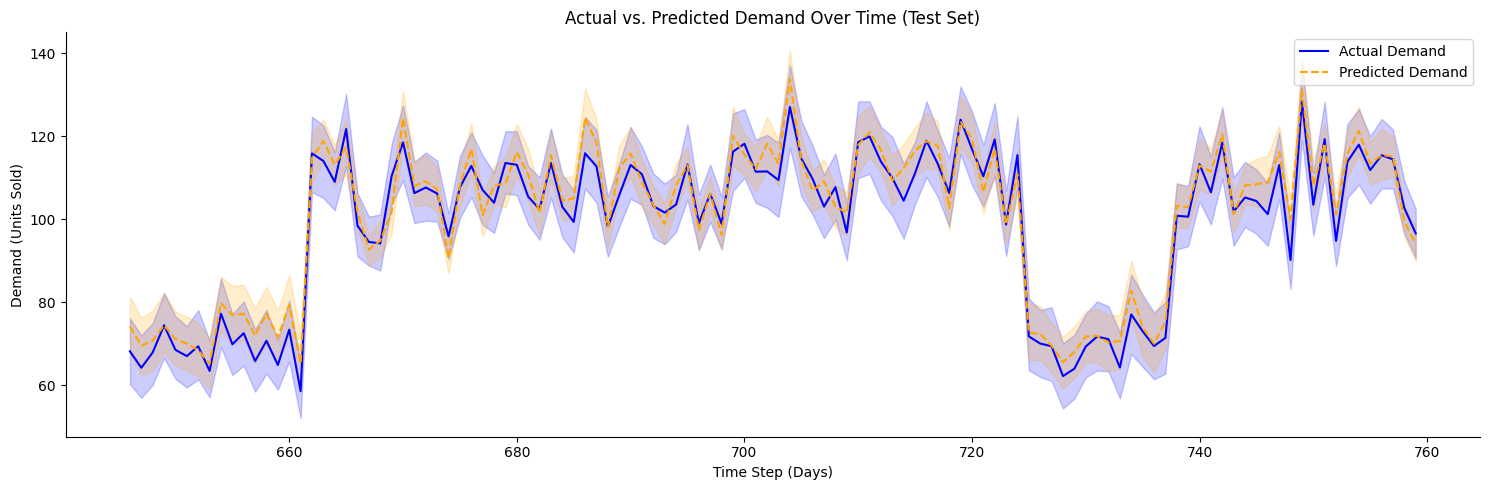

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create results_df from X_test, y_test, and y_pred
results_df = X_test[['Time_Step']].copy()
results_df['Actual_Demand'] = y_test
results_df['Predicted_Demand'] = y_pred

plt.figure(figsize=(15, 5))
sns.lineplot(data=results_df, x='Time_Step', y='Actual_Demand', label='Actual Demand', color='blue')
sns.lineplot(data=results_df, x='Time_Step', y='Predicted_Demand', label='Predicted Demand', color='orange', linestyle='--')

plt.title('Actual vs. Predicted Demand Over Time (Test Set)')
plt.xlabel('Time Step (Days)')
plt.ylabel('Demand (Units Sold)')
plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()